In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('df4_final_preparation.csv')
df

,Price,Total_Room,Bathroom_Count,Net_M2,Number_of_Floors,Floor,Furnished_Status,Is_New_Building,Is_Occupied,Is_Swap_Available,...,Tapu_Hisseli Mülkiyet,Tapu_Kat İrtifakı,Tapu_Tam Mülkiyet,Building_Type_Encoded,Ground_Risk,District,Neighborhood,District_Encoded,Neighborhood_Encoded,Price_Per_Sqrft
0,3750000,3,1.0,58,5,1.0,1,0,1,0,...,0,1,0,1,0.315789,Şişli,Şişli_Mecidiyeköy Mah.,1.155176e+07,7.811800e+06,64655.172414
1,7500000,4,1.0,120,3,2.0,0,0,1,0,...,0,0,0,1,0.578947,Sarıyer,Sarıyer_Ptt Evleri Mah.,3.467991e+07,1.119743e+07,62500.000000
2,9750000,4,1.0,120,5,5.0,0,0,1,0,...,0,0,1,1,0.578947,Şile,Şile_Çavuş Mah.,1.833398e+07,1.584995e+07,81250.000000
3,3975000,3,1.0,85,3,1.0,0,0,1,0,...,0,0,0,1,0.368421,Kadıköy,Kadıköy_Eğitim Mah.,2.089522e+07,9.224286e+06,46764.705882
4,4750000,3,1.0,85,5,2.0,1,0,0,0,...,0,0,1,1,0.315789,Şişli,Şişli_Eskişehir Mah.,1.154542e+07,4.559259e+06,55882.352941
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7044,7500000,2,1.0,75,12,1.0,0,0,1,0,...,0,0,1,1,0.263158,Beşiktaş,Beşiktaş_Gayrettepe Mah.,3.010328e+07,1.720333e+07,100000.000000
7045,7500000,6,2.0,150,5,5.0,0,0,1,0,...,0,1,0,0,0.789474,Sultangazi,Sultangazi_Eski Habipler Mah.,4.870294e+06,7.199500e+06,50000.000000
7046,9500000,7,2.0,160,4,4.0,0,0,1,0,...,0,0,1,1,0.736842,Kağıthane,Kağıthane_Nurtepe Mah.,6.584713e+06,5.592308e+06,59375.000000
7047,4250000,4,1.0,80,5,1.0,1,0,1,1,...,0,0,1,1,0.315789,Şişli,Şişli_Mecidiyeköy Mah.,1.147487e+07,7.336034e+06,53125.000000


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7049 entries, 0 to 7048
Data columns (total 41 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Price                            7049 non-null   int64  
 1   Total_Room                       7049 non-null   int64  
 2   Bathroom_Count                   7049 non-null   float64
 3   Net_M2                           7049 non-null   int64  
 4   Number_of_Floors                 7049 non-null   int64  
 5   Floor                            7049 non-null   float64
 6   Furnished_Status                 7049 non-null   int64  
 7   Is_New_Building                  7049 non-null   int64  
 8   Is_Occupied                      7049 non-null   int64  
 9   Is_Swap_Available                7049 non-null   int64  
 10  In_a_Complex                     7049 non-null   int64  
 11  Loan_Eligibility                 7049 non-null   int64  
 12  KonutTipi_Bina      

In [19]:
df.columns

Index(['Price', 'Total_Room', 'Bathroom_Count', 'Net_M2', 'Number_of_Floors',
       'Floor', 'Furnished_Status', 'Is_New_Building', 'Is_Occupied',
       'Is_Swap_Available', 'In_a_Complex', 'Loan_Eligibility',
       'KonutTipi_Bina', 'KonutTipi_Daire', 'KonutTipi_Kooperatif',
       'KonutTipi_Mustakil', 'KonutTipi_Yali', 'Age_0', 'Age_1-5', 'Age_6-10',
       'Age_11-20', 'Age_21-30', 'Age_31-40', 'Age_41-50', 'Age_51-70',
       'Heating_Diger-Belirsiz', 'Heating_Kombi-Bireysel Doğalgaz',
       'Heating_Merkezi Sistem', 'Heating_Soba-Geleneksel',
       'Heating_Yerden Isıtma-Modern', 'Tapu_Diger/Riskli',
       'Tapu_Hisseli Mülkiyet', 'Tapu_Kat İrtifakı', 'Tapu_Tam Mülkiyet',
       'Building_Type_Encoded', 'Ground_Risk', 'District', 'Neighborhood',
       'District_Encoded', 'Neighborhood_Encoded', 'Price_Per_Sqrft'],
      dtype='object')

# Dataset Analysis

### 1. Hedef Değişken (Fiyat) Dağılımı ve Log Dönüşümü

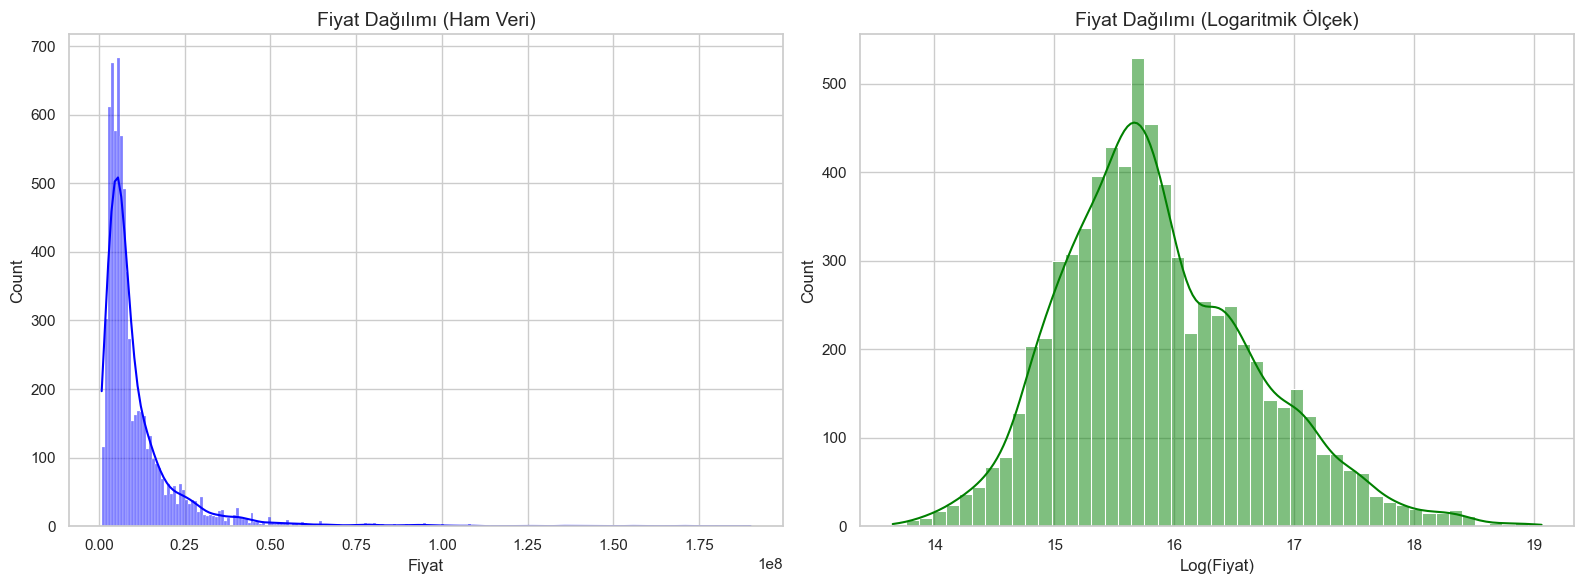

In [20]:
# Görselleştirme stilini ayarla
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

def plot_target_distribution(df):
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    
    # Ham Fiyat Dağılımı
    sns.histplot(df['Price'], kde=True, ax=ax[0], color='blue')
    ax[0].set_title('Fiyat Dağılımı (Ham Veri)', fontsize=14)
    ax[0].set_xlabel('Fiyat', fontsize=12)
    
    # Logaritmik Fiyat Dağılımı (Analiz için daha uygun olabilir)
    sns.histplot(np.log1p(df['Price']), kde=True, ax=ax[1], color='green')
    ax[1].set_title('Fiyat Dağılımı (Logaritmik Ölçek)', fontsize=14)
    ax[1].set_xlabel('Log(Fiyat)', fontsize=12)
    
    plt.tight_layout()
    plt.show()

plot_target_distribution(df)

### 2. Metrekare (Net_M2) ve Fiyat İlişkisi

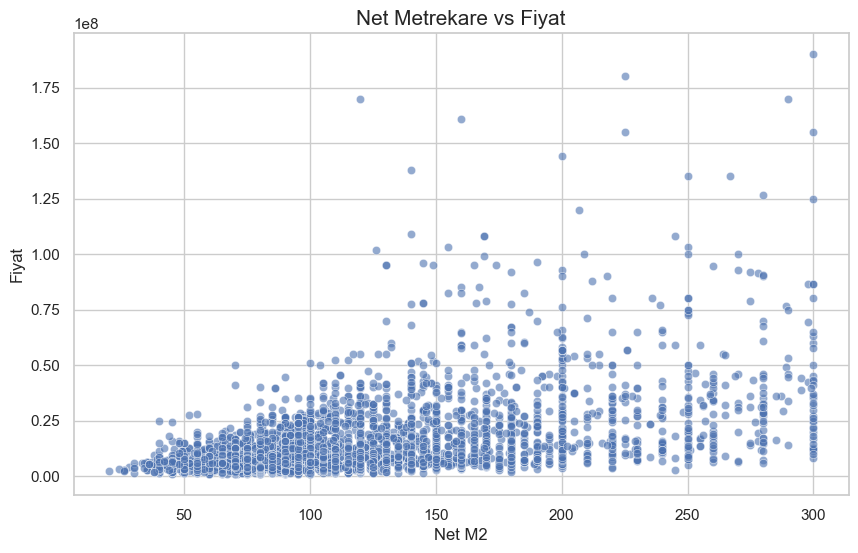

In [21]:
def plot_m2_vs_price(df):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='Net_M2', y='Price', alpha=0.6)
    plt.title('Net Metrekare vs Fiyat', fontsize=15)
    plt.xlabel('Net M2', fontsize=12)
    plt.ylabel('Fiyat', fontsize=12)
    plt.show()

plot_m2_vs_price(df)

### 3. Bina Yaşı ve Fiyat Analizi (Kategorik Karşılaştırma)

C:\Users\emir\AppData\Local\Temp\ipykernel_16680\2815625364.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_cols, y=age_means, palette='coolwarm')


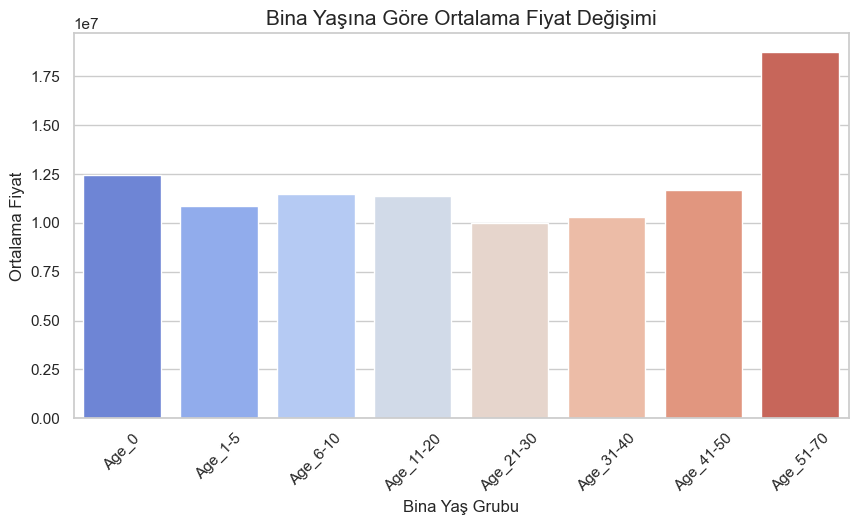

In [22]:
def plot_age_impact(df):
    # Yaş sütunlarını birleştirip analiz etmek için geçici bir dataframe
    age_cols = ['Age_0', 'Age_1-5', 'Age_6-10', 'Age_11-20', 'Age_21-30', 'Age_31-40', 'Age_41-50', 'Age_51-70']
    age_means = [df[df[col] == 1]['Price'].mean() for col in age_cols]
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=age_cols, y=age_means, palette='coolwarm')
    plt.title('Bina Yaşına Göre Ortalama Fiyat Değişimi', fontsize=15)
    plt.ylabel('Ortalama Fiyat', fontsize=12)
    plt.xlabel('Bina Yaş Grubu', fontsize=12)
    plt.xticks(rotation=45)
    plt.show()

plot_age_impact(df)

### 4. Korelasyon Isı Haritası (Kritik Özellikler)

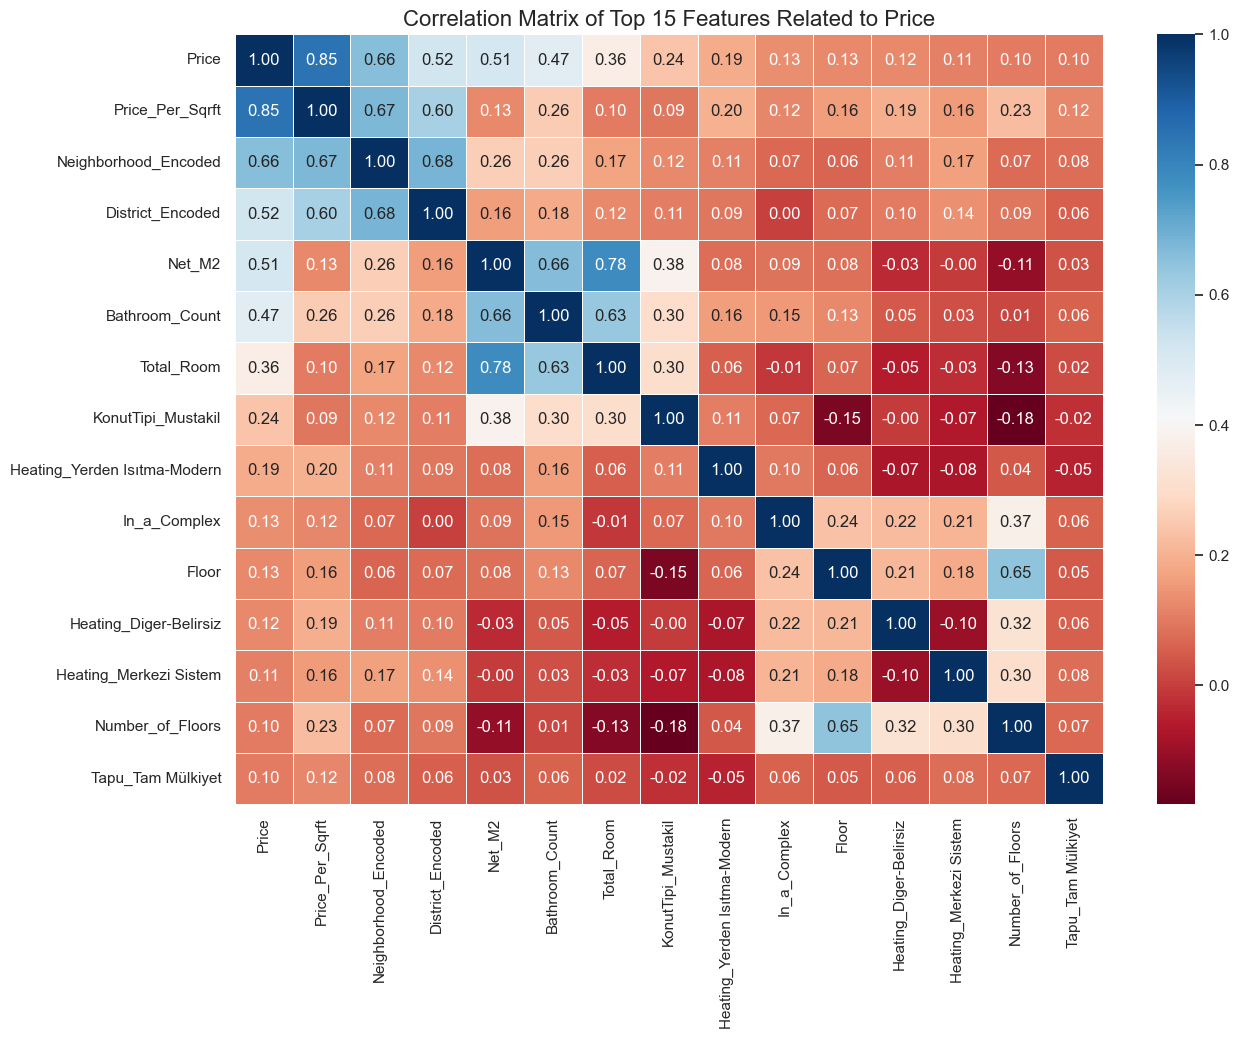

In [23]:
def plot_correlation_heatmap(df):
    plt.figure(figsize=(14, 10))
    
    # numeric_only=True ekleyerek metin sütunlarını (District, Neighborhood) devre dışı bırakıyoruz
    # Price ile en yüksek korelasyona sahip 15 özelliği seçiyoruz
    top_corr_features = df.corr(numeric_only=True)['Price'].sort_values(ascending=False).head(15).index
    
    # Korelasyon matrisini oluşturma
    correlation_matrix = df[top_corr_features].corr()
    
    # Heatmap çizimi
    sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', fmt=".2f", linewidths=0.5)
    
    plt.title('Correlation Matrix of Top 15 Features Related to Price', fontsize=16)
    
    # Görseli kaydetme (show'dan önce!)
    plt.savefig('Figure_correlation_heatmap.png', dpi=300, bbox_inches='tight')
    
    plt.show()

plot_correlation_heatmap(df)

C:\Users\emir\AppData\Local\Temp\ipykernel_16680\3271243779.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_filtered, x='District', y='Price', palette='Set3')


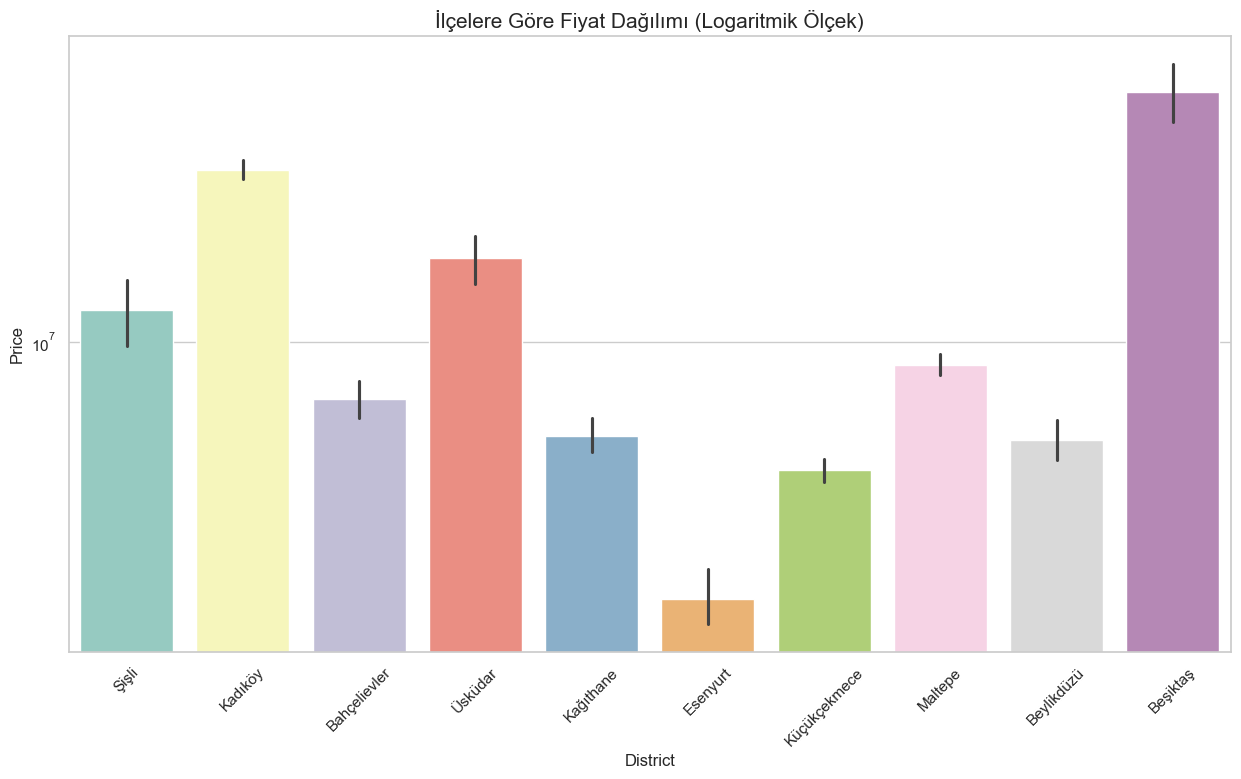

In [24]:
def plot_district_prices(df):
    plt.figure(figsize=(15, 8))
    # En çok veri olan ilk 10 ilçeyi seçelim (görselin karışmaması için)
    top_districts = df['District'].value_counts().nlargest(10).index
    df_filtered = df[df['District'].isin(top_districts)]
    
    sns.barplot(data=df_filtered, x='District', y='Price', palette='Set3')
    plt.yscale('log') # Fiyat farkları çoksa logaritmik eksen daha iyi gösterir
    plt.title('İlçelere Göre Fiyat Dağılımı (Logaritmik Ölçek)', fontsize=15)
    plt.xticks(rotation=45)
    plt.show()

plot_district_prices(df)

# Model Analysis

## Model Karşılaştırma

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import GroupShuffleSplit
# Lasso modelini buraya ekledik
from sklearn.linear_model import LinearRegression, Ridge, Lasso 
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# --- 1. Veri Hazırlığı (Senin yapına göre) ---
# Not: df'in daha önce tanımlandığını varsayıyoruz.
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(df, groups=df['District']))
train, test = df.iloc[train_idx].copy(), df.iloc[test_idx].copy()

# Target Encoding
dist_map = train.groupby('District')['Price'].mean()
neigh_map = train.groupby('Neighborhood')['Price'].mean()
global_mean = train['Price'].mean()

for dataset in [train, test]:
    dataset['District_Encoded'] = dataset['District'].map(dist_map).fillna(global_mean)
    dataset['Neighborhood_Encoded'] = dataset['Neighborhood'].map(neigh_map).fillna(global_mean)

X_train = train.drop(columns=['Price', 'District', 'Neighborhood', "Ground_Risk"])
y_train = train['Price']
X_test = test.drop(columns=['Price', 'District', 'Neighborhood', "Ground_Risk"])
y_test = test['Price']

# --- 2. Model Tanımlamaları (Lasso Eklendi) ---
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    # Lasso buraya eklendi. alpha parametresi regülarizasyon şiddetini belirler.
    "Lasso Regression": Lasso(alpha=1.0, random_state=42), 
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, subsample=0.8, colsample_bytree=0.8, random_state=42)
}

# --- 3. Eğitim ve Metrik Hesaplama ---
results = []

print("Training models...")
for name, model in models.items():
    # Eğit
    model.fit(X_train, y_train)
    # Tahmin
    y_pred = model.predict(X_test)
    
    # Metrikler
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append({
        "Model": name,
        "R2_Score": r2,
        "MAE": mae,
        "RMSE": rmse
    })
    print(f"Finished: {name}")

# Sonuçları DataFrame yap
comparison_df = pd.DataFrame(results).sort_values(by="R2_Score", ascending=False)
print("\n--- Model Comparison Table ---")
print(comparison_df)

Training models...
Finished: Linear Regression
Finished: Ridge Regression


C:\Users\emir\anaconda3\envs\tf_env\lib\site-packages\sklearn\linear_model\_ridge.py:212: LinAlgWarning: Ill-conditioned matrix (rcond=1.16093e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\emir\anaconda3\envs\tf_env\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.836e+15, tolerance: 9.634e+13
  model = cd_fast.enet_coordinate_descent(


Finished: Lasso Regression
Finished: Random Forest
Finished: Gradient Boosting
Finished: XGBoost

--- Model Comparison Table ---
               Model  R2_Score           MAE          RMSE
4  Gradient Boosting  0.983770  4.493665e+05  2.128228e+06
3      Random Forest  0.973478  4.972548e+05  2.720546e+06
5            XGBoost  0.946528  7.355177e+05  3.862968e+06
0  Linear Regression  0.858534  2.669274e+06  6.283209e+06
2   Lasso Regression  0.858516  2.669621e+06  6.283619e+06
1   Ridge Regression  0.858489  2.669086e+06  6.284226e+06


C:\Users\emir\AppData\Local\Temp\ipykernel_16680\3080414758.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2_Score', data=df_results, ax=ax1, palette='viridis', alpha=0.7)


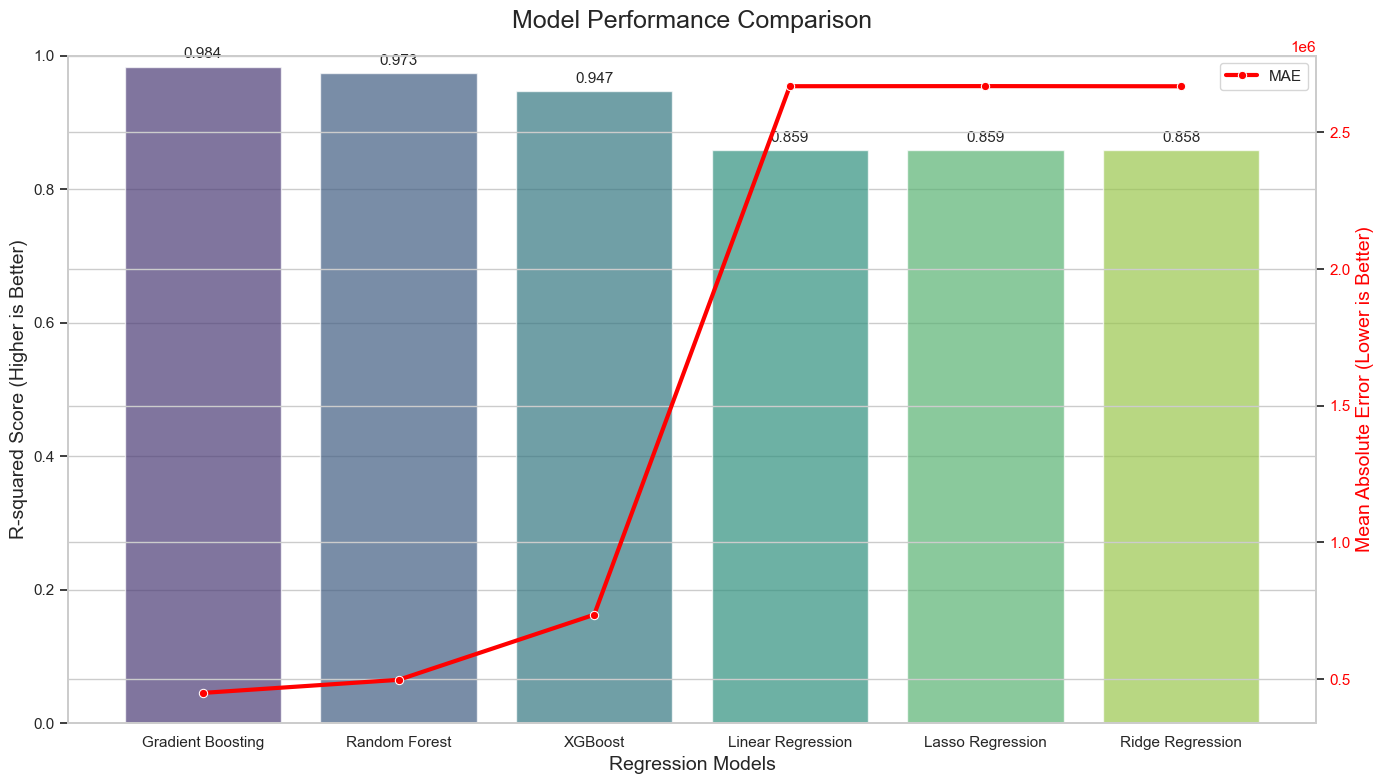

In [26]:
def plot_model_comparison_professional(df_results):
    sns.set_style("whitegrid")
    fig, ax1 = plt.subplots(figsize=(14, 8))

    # Bar Plot for R2 Score
    sns.barplot(x='Model', y='R2_Score', data=df_results, ax=ax1, palette='viridis', alpha=0.7)
    ax1.set_title('Model Performance Comparison', fontsize=18, pad=20)
    ax1.set_xlabel('Regression Models', fontsize=14)
    ax1.set_ylabel('R-squared Score (Higher is Better)', fontsize=14)
    ax1.set_ylim(0, 1.0) # Eğer R2 negatif çıkarsa burayı esnetmek gerekebilir
    
    # Değerleri barların üzerine yazma
    for p in ax1.patches:
        ax1.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=11)

    # Line Plot for MAE
    ax2 = ax1.twinx()
    sns.lineplot(x='Model', y='MAE', data=df_results, marker='o', color='red', ax=ax2, linewidth=3, label='MAE')
    ax2.set_ylabel('Mean Absolute Error (Lower is Better)', fontsize=14, color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    
    plt.tight_layout()
    plt.savefig('Figure 1.1_model_comparison_results.png', dpi=300, bbox_inches='tight') # İsterseniz kaydedebilirsiniz
    plt.show()

plot_model_comparison_professional(comparison_df)

### XGBoost model

In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
import math
from sklearn.model_selection import GroupShuffleSplit
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('df4_final_preparation.csv')

# --- 1. Veri bölme ---
#train, test = train_test_split(df, test_size=0.2, random_state=42)

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(df, groups=df['District']))
train, test = df.iloc[train_idx], df.iloc[test_idx]

# --- 2. Target encoding (sızıntısız) ---
dist_map = train.groupby('District')['Price'].mean()
neigh_map = train.groupby('Neighborhood')['Price'].mean()

train.loc[:, 'District_Encoded'] = train['District'].map(dist_map)
test.loc[:, 'District_Encoded'] = test['District'].map(dist_map)

train.loc[:, 'Neighborhood_Encoded'] = train['Neighborhood'].map(neigh_map)
test.loc[:, 'Neighborhood_Encoded'] = test['Neighborhood'].map(neigh_map)

global_mean = train['Price'].mean()
test.loc[:, 'District_Encoded'] = test['District_Encoded'].fillna(global_mean)
test.loc[:, 'Neighborhood_Encoded'] = test['Neighborhood_Encoded'].fillna(global_mean)

# --- 3. Model girdilerini hazırla ---
X_train = train.drop(columns=['Price', 'District', 'Neighborhood',"Ground_Risk"])
y_train = train['Price']
X_test = test.drop(columns=['Price', 'District', 'Neighborhood',"Ground_Risk"])
y_test = test['Price']

# --- 4. XGBoost ---
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("\nXGBoost:")
print(f"  R²: {r2_score(y_test, y_pred_xgb):.4f}")
print(f"  MAE: {mean_absolute_error(y_test, y_pred_xgb):,.0f} TL")
print(f"  RMSE: {math.sqrt(mean_squared_error(y_test, y_pred_xgb)):,.0f} TL")


XGBoost:
  R²: 0.9465
  MAE: 735,518 TL
  RMSE: 3,862,968 TL


### 1. Actual vs. Predicted Prices

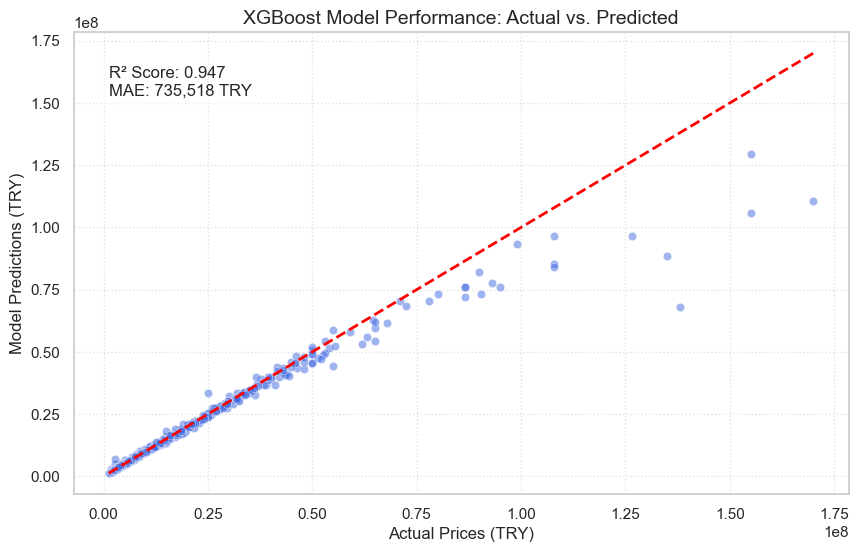

In [28]:
def plot_actual_vs_predicted(y_test, y_pred):
    plt.figure(figsize=(10, 6))
    
    # Actual vs Predicted scatter plot
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='royalblue')
    
    # Perfect prediction line (y=x)
    max_val = max(y_test.max(), y_pred.max())
    min_val = min(y_test.min(), y_pred.min())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', lw=2, linestyle='--')
    
    # Metrics annotation
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    # Note: 'TRY' is used for Turkish Lira in academic papers
    plt.text(min_val, max_val*0.9, f'R² Score: {r2:.3f}\nMAE: {mae:,.0f} TRY', 
             fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

    plt.xlabel('Actual Prices (TRY)', fontsize=12)
    plt.ylabel('Model Predictions (TRY)', fontsize=12)
    plt.title('XGBoost Model Performance: Actual vs. Predicted', fontsize=14)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.savefig('Figure_1. Actual vs. Predicted Prices.png', dpi=300, bbox_inches='tight')
    plt.show()


y_pred = xgb_model.predict(X_test)
plot_actual_vs_predicted(y_test, y_pred)

### 2. Residual Analysis

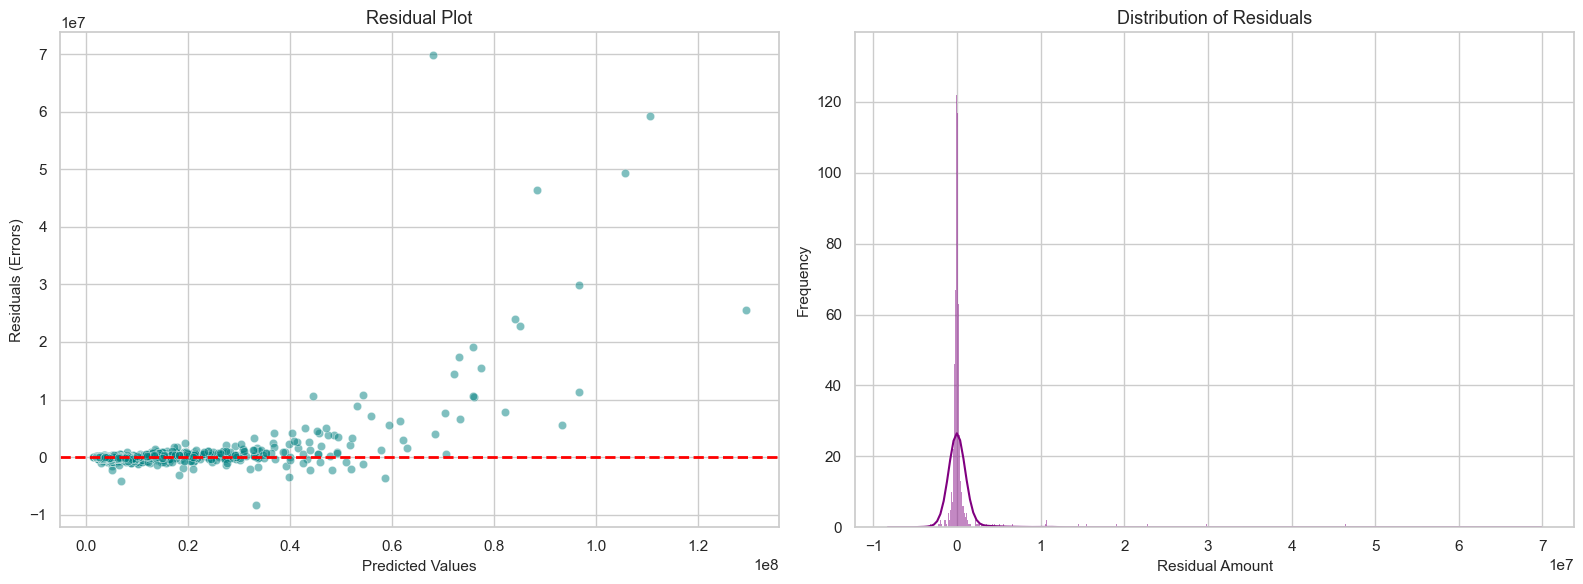

In [29]:
def plot_residuals(y_test, y_pred):
    residuals = y_test - y_pred
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Residual Scatter Plot
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, ax=ax[0], color='teal')
    ax[0].axhline(y=0, color='red', linestyle='--', lw=2)
    ax[0].set_title('Residual Plot', fontsize=13)
    ax[0].set_xlabel('Predicted Values', fontsize=11)
    ax[0].set_ylabel('Residuals (Errors)', fontsize=11)
    
    # 2. Distribution of Residuals (Histogram)
    sns.histplot(residuals, kde=True, ax=ax[1], color='purple')
    ax[1].set_title('Distribution of Residuals', fontsize=13)
    ax[1].set_xlabel('Residual Amount', fontsize=11)
    ax[1].set_ylabel('Frequency', fontsize=11)
    
    plt.tight_layout()
    plt.savefig('Figure_2. Residual Analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_residuals(y_test, y_pred)

### 3. Feature Importance

C:\Users\emir\AppData\Local\Temp\ipykernel_16680\83188789.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp, palette='magma')


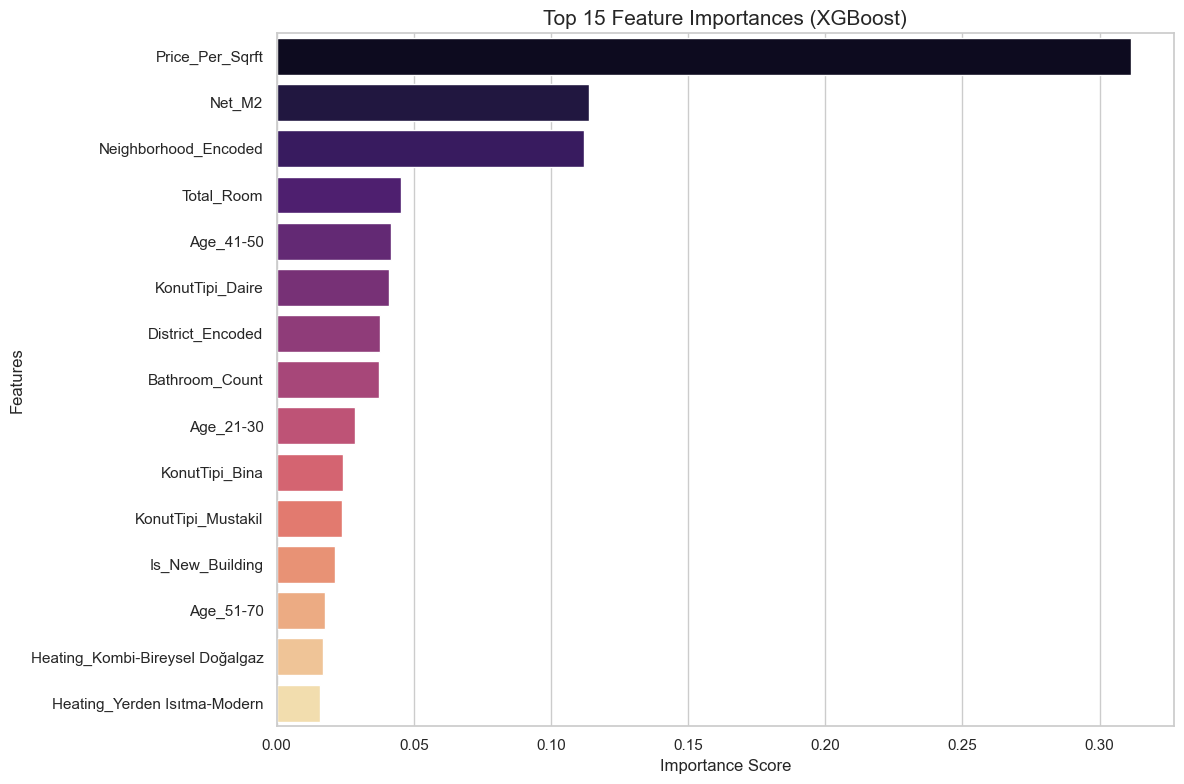

In [30]:
def plot_feature_importance(model, feature_names):
    # Get feature importance scores
    importances = model.feature_importances_
    
    # Create DataFrame for visualization
    feature_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feature_imp = feature_imp.sort_values(by='Importance', ascending=False).head(15)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_imp, palette='magma')
    
    plt.title('Top 15 Feature Importances (XGBoost)', fontsize=15)
    plt.xlabel('Importance Score', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.tight_layout()
    plt.savefig('Figure_3. Feature Importance.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_feature_importance(xgb_model, X_train.columns)

### 4. Percentage Error Distribution

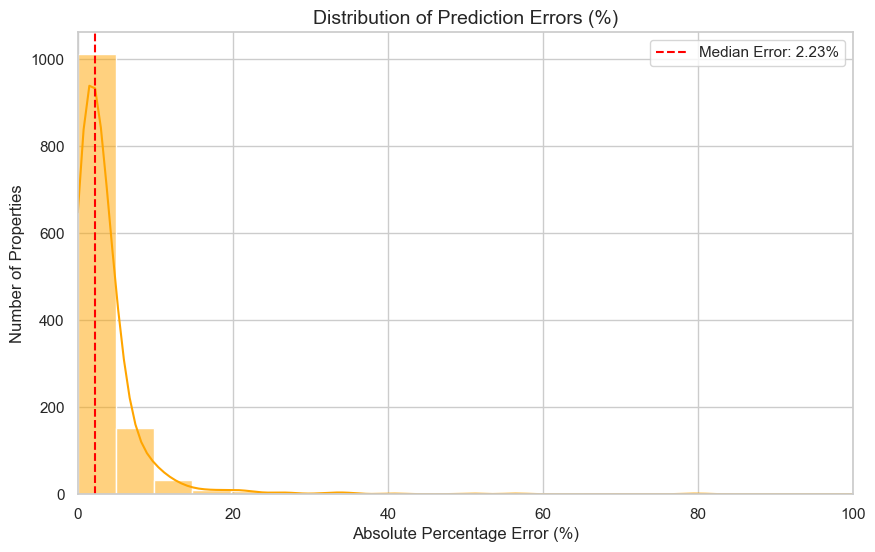

In [31]:
def plot_error_percentage(y_test, y_pred):
    # Calculate Absolute Percentage Error
    error_pct = abs((y_test - y_pred) / y_test) * 100
    
    plt.figure(figsize=(10, 6))
    sns.histplot(error_pct, bins=30, kde=True, color='orange')
    plt.axvline(error_pct.median(), color='red', linestyle='--', 
                label=f'Median Error: {error_pct.median():.2f}%')
    
    plt.title('Distribution of Prediction Errors (%)', fontsize=14)
    plt.xlabel('Absolute Percentage Error (%)', fontsize=12)
    plt.ylabel('Number of Properties', fontsize=12)
    plt.legend()
    plt.xlim(0, 100) # Limits x-axis to 100% for better readability
    plt.savefig('Figure_4. Percentage Error Distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_error_percentage(y_test, y_pred)